In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

### Create a fake dataset 

This dataset is a simple polynomial regression problem with a small it of noise

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

### Create expressions

1. The first expression is a rolling mean of the species count for visualization purposes.
2. The second expression calculates the error of the species count rolling mean compared to the current species count.
3. The third expression calculates a threshold for the NEAT distance based on the last species threshold. 

The third threshold is essentially equivalent to something like

```python
def species_threshold(target_species: int) -> rd.Expr:
    GAIN = 0.3
    target = float(max(target_species, 1))

    count_error = (
        rd.Expr.select("count.species").rolling(target_species).mean() - target
    ) / target

    step = (count_error * GAIN + 1.0).clamp(0.8, 1.5)
    prev = rd.Expr.select("species.threshold").last()

    result = (prev * step).clamp(0.005, 2.0)
    return result
```

In [ ]:
target_species = 5

rolling_species_count = rd.Expr.select("count.species").rolling(25).mean()
species_count_error = (
    rd.Expr.select("count.species").rolling(target_species).mean().error(target_species)
)

threshold = rd.Expr.track(
    "count.species",
    target=target_species,
    anchor=rd.Expr.select("species.threshold").last(),
    gain=0.3,
)

### Create the engine

This engine evolves `rd.Graph`s to fit the polynomial regression problem. The vertices of the graph are only allowed to use addition, multiplication, and constants. The engine also tracks the species count and species threshold as metrics, and uses the NEAT distance as a diversity metric.

In [4]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), threshold)
    .metrics(
        species_rolling=rolling_species_count,
        species_count_error=species_count_error,
        other_threshold=threshold,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-06-01T00:09:47.208929Z  INFO Epoch 1    | Score:   2.0038 | Time: 223.62µs
2026-06-01T00:09:47.209089Z  INFO Epoch 2    | Score:   1.6821 | Time: 326.29µs
2026-06-01T00:09:47.209236Z  INFO Epoch 3    | Score:   1.6821 | Time: 435.04µs
2026-06-01T00:09:47.209406Z  INFO Epoch 4    | Score:   1.6821 | Time: 565.33µs
2026-06-01T00:09:47.209633Z  INFO Epoch 5    | Score:   1.6820 | Time: 743.79µs
2026-06-01T00:09:47.209893Z  INFO Epoch 6    | Score:   1.6820 | Time: 953.75µs
2026-06-01T00:09:47.210189Z  INFO Epoch 7    | Score:   1.6820 | Time: 1.19ms
2026-06-01T00:09:47.210449Z  INFO Epoch 8    | Score:   1.6820 | Time: 1.40ms
2026-06-01T00:09:47.210608Z  INFO Epoch 9    | Score:   1.6651 | Time: 1.51ms
2026-06-01T00:09:47.210773Z  INFO Epoch 10   | Score:   1.6651 | Time: 1.63ms
2026-06-01T00:09:47.210919Z  INFO Epoch 11   | Score:   1.6651 | Time: 1.75ms
2026-06-01T00:09:47.211132Z  INFO Epoch 12   | Score:   1.6651 | Time: 1.91ms
2026-06-01T00:09:47.211295Z  INFO Epoch 13   | Score

### Metrics

Using the `rd.MetricCollector` we can aggregate the metrics for the whole engine's run and visualize the metrics we want to track here once the engine has finished. In this case we only want to see our three expressions, but we could also see any `rd.Metric` that the engine tracks - refer to the docs for more details.

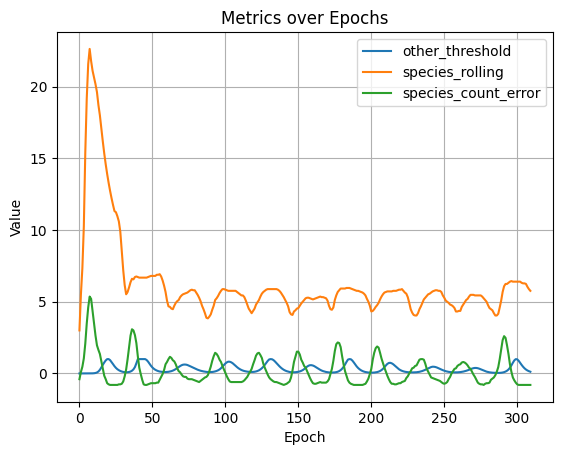

In [5]:
collector.plot("other_threshold", "species_rolling", "species_count_error")

In [6]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species")
# df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",3.0,3.0,3.0,0.0,0.0,NaN,3.0,3.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
"""count.species""",8.0,11.0,5.5,3.535534,12.5,NaN,3.0,8.0,2,null,null,null,null,null,null,1,1,"[""species"", ""statistic""]"
"""count.species""",11.0,22.0,7.333333,4.041452,16.333334,-1.532828,3.0,11.0,3,null,null,null,null,null,null,2,1,"[""species"", ""statistic""]"
"""count.species""",19.0,41.0,10.25,6.70199,44.916668,0.991255,3.0,19.0,4,null,null,null,null,null,null,3,1,"[""species"", ""statistic""]"
"""count.species""",36.0,77.0,15.4,12.895736,166.300003,1.755211,3.0,36.0,5,null,null,null,null,null,null,4,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",1.0,1798.0,5.875817,5.986126,35.83371,2.317525,1.0,38.0,306,null,null,null,null,null,null,305,1,"[""species"", ""statistic""]"
"""count.species""",1.0,1799.0,5.859935,5.982812,35.794044,2.320354,1.0,38.0,307,null,null,null,null,null,null,306,1,"[""species"", ""statistic""]"
"""count.species""",1.0,1800.0,5.844156,5.979476,35.754135,2.323205,1.0,38.0,308,null,null,null,null,null,null,307,1,"[""species"", ""statistic""]"


In [7]:
df = collector.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.evaluation""",8.0,108.0,54.0,65.053825,4232.0,NaN,8.0,100.0,2,null,null,null,null,null,null,0,2,"[""statistic""]"
"""step.evaluate.time""",0.000012,0.000071,0.000036,0.000033,1.0599e-9,NaN,0.000012,0.000059,2,71µs,35µs,32µs,12µs,58µs,0µs,0,2,"[""time"", ""step""]"
"""selector.roulette""",20.0,20.0,20.0,0.0,0.0,NaN,20.0,20.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
"""selector.roulette.time""",0.000006,0.000006,0.000006,0.0,0.0,NaN,0.000006,0.000006,1,5µs,5µs,0µs,5µs,5µs,0µs,0,1,"[""selector"", ""time""]"
"""selector.tournament""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""scores.best""",0.000987,95.411125,0.307778,0.510959,0.26108,0.0,0.000987,2.003778,310,null,null,null,null,null,null,309,1,"[""statistic"", ""score""]"
"""species_rolling""",5.76,1949.728516,6.289447,3.191901,10.188232,4.020912,3.0,22.625,310,null,null,null,null,null,null,309,1,"[""species"", ""statistic"", ""expr""]"
"""species_count_error""",-0.8,52.136673,0.168183,1.066057,1.136477,45.410633,-0.8,5.36,310,null,null,null,null,null,null,309,1,"[""species"", ""statistic"", ""expr""]"


In [8]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

310


309